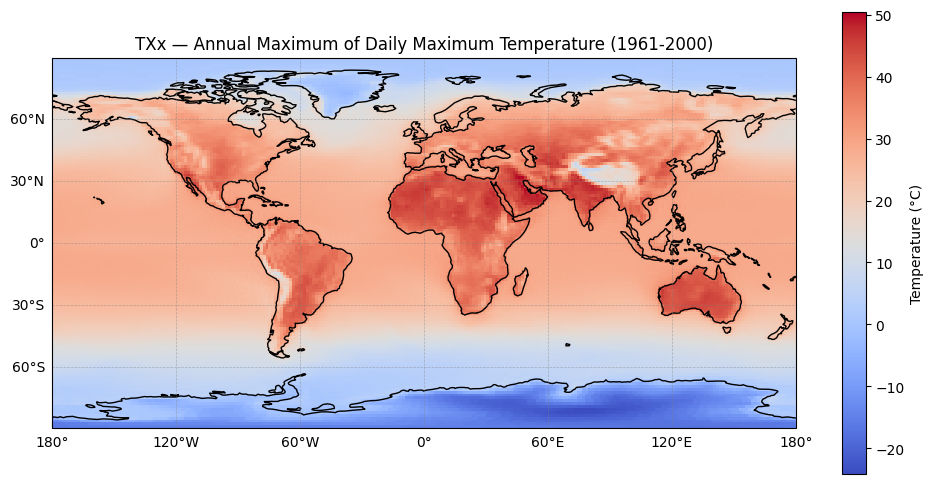

In [15]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# open the dataset
ds = xr.open_dataset("/media/wcs/Disk3/abbas/etccdi_extreme_indices/cei_absolute/indices/txx_yr_CNRM-ESM2-1_historical_r1i1p1f2_1961-2000.nc")

# select variable
var = ds['tasmax']

# average over all years
mean_map = var.mean(dim='time')

# color bar values
vmin = mean_map.min().values
vmax = mean_map.max().values

# create a global map
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# Draw the data
mean_map.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    vmin=vmin,
    vmax=vmax,
    cmap='coolwarm',
    cbar_kwargs={'label': 'Temperature (°C)'})

ax.coastlines()
plt.title('TXx — Annual Maximum of Daily Maximum Temperature (1961-2000)')
plt.show()

Text(0.5, 1.0, 'Global Mean TXx (1961-2000)')

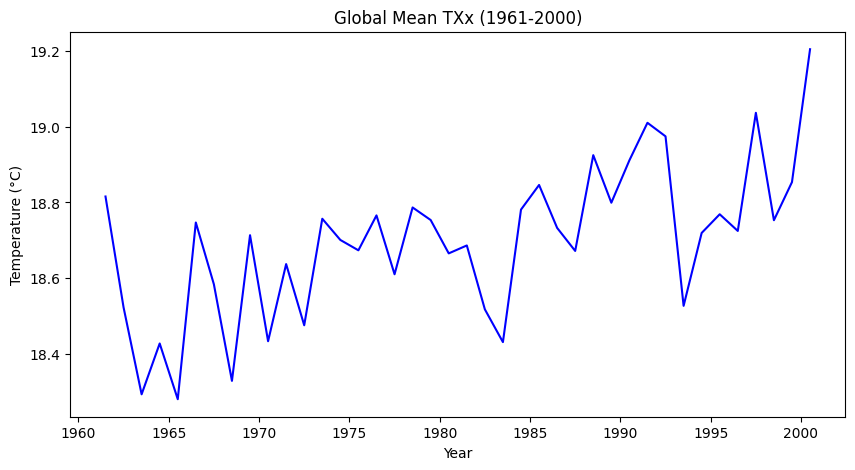

In [16]:
# Time series (ts) of global mean
ts = ds['tasmax'].mean(dim=("lat", "lon"))

ts.plot(figsize=(10, 5), color='blue', linewidth=1.5)
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.title("Global Mean TXx (1961-2000)")